# Cybersecurity Dataset: Nonlinear Case

This notebook uses a **account-compromise detection** dataset. The dataset is non-linear and **linear model** (logistic regression) performs poorly, while a **small neural network** performs much better.

## Why this dataset is nonlinear
The target label is driven mainly by a **ring-shaped pattern** in these two behavioral features:

- `off_hours_score`
- `sensitive_file_access_score`

A linear classifier can only draw a straight decision boundary, which cannot separate a ring well.  
A small neural network can learn that nonlinear boundary.

## Files
This notebook expects the CSV file to be in the same folder:

`Lab15-cyber_nonlinear_account_compromise_dataset.csv`


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

plt.rcParams["figure.figsize"] = (7, 5)
pd.set_option("display.max_columns", None)

In [10]:
csv_path = "Lab15-cyber_nonlinear_account_compromise_dataset.csv"

if not os.path.exists(csv_path):
    df = generate_dataset()
    df.to_csv(csv_path, index=False)

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Positive rate:", round(df["label"].mean(), 4))
df.head()

Shape: (5000, 19)
Positive rate: 0.4976


,record_id,off_hours_score,sensitive_file_access_score,failed_login_rate,new_device,new_geo,dns_entropy,beacon_regularity,process_injection_score,privilege_escalation_score,lateral_movement_score,session_duration_min,url_similarity_to_brand,noise_1,noise_2,noise_3,noise_4,noise_5,label
0,1,0.2273,0.2830,0.1332,1,0,0.5696,0.6483,0.3469,0.2346,0.2076,42.87,0.4003,0.9616,0.6473,0.2098,-1.4264,1.6756,0
1,2,0.6517,0.4837,0.1467,1,0,0.5883,0.3151,0.2344,0.5164,0.2678,19.75,0.2531,0.0586,0.3118,-0.7050,-0.2148,1.1794,1
2,3,0.6419,0.5619,0.2339,1,0,0.5591,0.6342,0.3092,0.4714,0.2282,36.35,0.3271,0.7827,-0.3113,1.5277,-1.0093,-1.6808,1
3,4,0.1258,0.7172,0.1668,0,1,0.4742,0.4754,0.1675,0.3899,0.3788,30.92,0.3416,-1.9292,0.7949,-0.6961,-0.1404,1.0944,0
4,5,0.4542,0.8810,0.2506,1,0,0.5248,0.3381,0.1644,0.1060,0.2947,32.84,0.5320,0.3287,-1.1861,1.6242,-0.2910,-0.0629,0


## Train/test split and preprocessing

In [11]:
target = "label"
feature_cols = [c for c in df.columns if c not in ["label", "record_id"]]

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols)
    ]
)

## Compare a linear model vs a simple neural network

In [12]:
log_reg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

mlp = Pipeline([
    ("preprocess", preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        max_iter=800,
        random_state=42,
        early_stopping=True
    ))
])

models = {
    "Logistic Regression (linear)": log_reg,
    "MLP Neural Network": mlp
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df

,model,accuracy,f1,roc_auc
1,MLP Neural Network,0.972667,0.972757,0.977882
0,Logistic Regression (linear),0.496667,0.494983,0.511634


## Visualize the nonlinear pattern

These two features are the main nonlinear driver of the label.  
If you plot them, the malicious class forms a ring-like region.

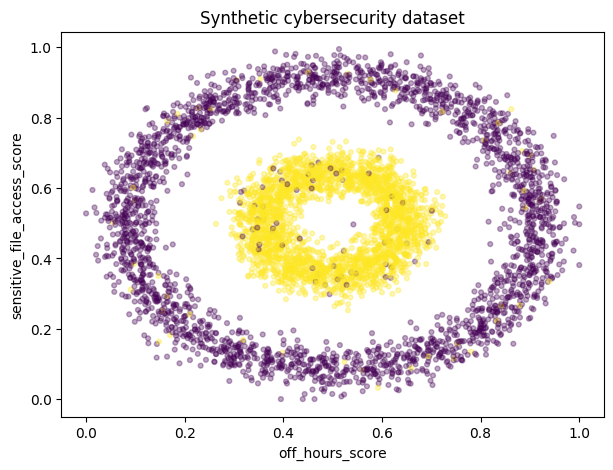

In [13]:
plt.figure()
plt.scatter(
    df["off_hours_score"],
    df["sensitive_file_access_score"],
    c=df["label"],
    alpha=0.35,
    s=12
)
plt.xlabel("off_hours_score")
plt.ylabel("sensitive_file_access_score")
plt.title("Synthetic cybersecurity dataset")
plt.show()

## Confusion matrices

In [14]:
for name, model in models.items():
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    print("\n" + name)
    print(pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    ))


Logistic Regression (linear)
          Predicted 0  Predicted 1
Actual 0          375          379
Actual 1          376          370

MLP Neural Network
          Predicted 0  Predicted 1
Actual 0          727           27
Actual 1           14          732


## Optional: 2-feature decision boundary demo

To make the geometry easy to see, this section trains the models using only:

- `off_hours_score`
- `sensitive_file_access_score`

The linear model should struggle, while the neural network should fit the ring.

In [15]:
two_features = ["off_hours_score", "sensitive_file_access_score"]
X2 = df[two_features]
y2 = df["label"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

pre2 = ColumnTransformer([
    ("num", StandardScaler(), two_features)
])

log_reg_2 = Pipeline([
    ("preprocess", pre2),
    ("model", LogisticRegression(max_iter=2000))
])

mlp_2 = Pipeline([
    ("preprocess", pre2),
    ("model", MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        max_iter=800,
        random_state=42,
        early_stopping=True
    ))
])

log_reg_2.fit(X2_train, y2_train)
mlp_2.fit(X2_train, y2_train)

comparison = pd.DataFrame([
    {
        "model": "Logistic Regression (2 features)",
        "accuracy": accuracy_score(y2_test, log_reg_2.predict(X2_test)),
        "f1": f1_score(y2_test, log_reg_2.predict(X2_test)),
        "roc_auc": roc_auc_score(y2_test, log_reg_2.predict_proba(X2_test)[:, 1]),
    },
    {
        "model": "MLP Neural Network (2 features)",
        "accuracy": accuracy_score(y2_test, mlp_2.predict(X2_test)),
        "f1": f1_score(y2_test, mlp_2.predict(X2_test)),
        "roc_auc": roc_auc_score(y2_test, mlp_2.predict_proba(X2_test)[:, 1]),
    },
])

comparison

,model,accuracy,f1,roc_auc
0,Logistic Regression (2 features),0.336667,0.091324,0.487525
1,MLP Neural Network (2 features),0.972000,0.972037,0.978438


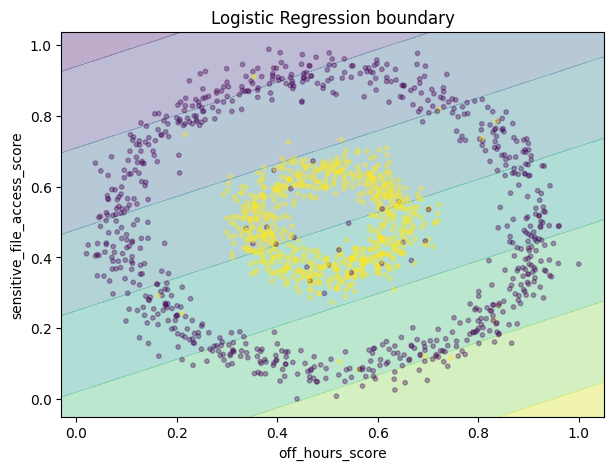

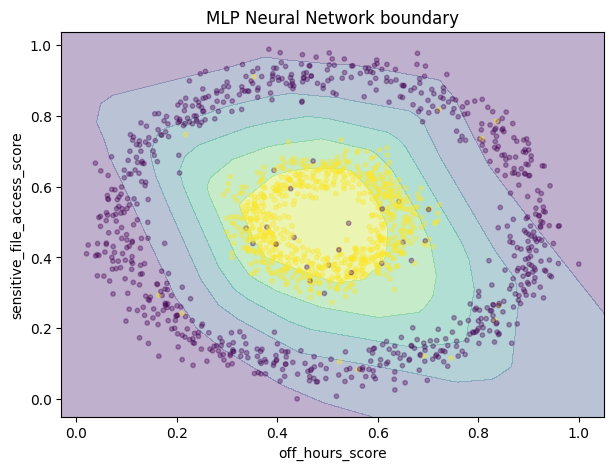

In [16]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X.iloc[:, 0].min() - 0.05, X.iloc[:, 0].max() + 0.05
    y_min, y_max = X.iloc[:, 1].min() - 0.05, X.iloc[:, 1].max() + 0.05

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid = pd.DataFrame({
        X.columns[0]: xx.ravel(),
        X.columns[1]: yy.ravel()
    })

    zz = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, zz, alpha=0.35)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=10, alpha=0.35)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    plt.show()

plot_decision_boundary(log_reg_2, X2_test, y2_test, "Logistic Regression boundary")
plot_decision_boundary(mlp_2, X2_test, y2_test, "MLP Neural Network boundary")

## Takeaway

This dataset is a good demo for cybersecurity ML classes because:

- the features look like a security monitoring table
- a **simple neural network** can model the ring-shaped boundary
- a **linear model** cannot separate the classes well
